<a href="https://colab.research.google.com/github/ameemaiqbal/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ameemaiqbal/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [13]:
%pip -q install duckdb huggingface_hub
import os, getpass, pandas as pd, numpy as np
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

import duckdb
con = duckdb.connect()
con.execute("CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '" + HF_TOKEN + "')")
REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {}
TABLES['dim_content'] = "read_parquet('" + REL + "/dim_content.parquet')"
TABLES['fact_daily_sample'] = "read_parquet('" + REL + "/fact_content_daily_performance_sample.parquet')"
print("Connected")

Connected


## 1. Question

*The research question and the decision it supports.*

Research question: Can short-term ranking (position) volatility serve as an early-warning signal for content decline, before impression loss becomes obvious?
Decision it supports: Which pages a content team should prioritize for manual review each week, given limited review capacity, before a page's traffic has already visibly dropped.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [14]:
sql_query = "WITH bounds AS (SELECT MAX(report_date) AS end_d FROM " + TABLES['fact_daily_sample'] + "), "
sql_query += "windowed AS ("
sql_query += "SELECT f.client_hash_id, f.content_hash_id, "
sql_query += "SUM(CASE WHEN f.report_date > b.end_d - INTERVAL 15 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last15, "
sql_query += "SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 15 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev15, "
sql_query += "STDDEV(CASE WHEN f.report_date > b.end_d - INTERVAL 15 DAY THEN f.gsc_avg_position END) AS position_volatility "
sql_query += "FROM " + TABLES['fact_daily_sample'] + " f, bounds b "
sql_query += "WHERE f.report_date > b.end_d - INTERVAL 30 DAY "
sql_query += "GROUP BY 1, 2 "
sql_query += "HAVING imp_prev15 >= 50) "
sql_query += "SELECT * FROM windowed"

features = con.sql(sql_query).df()
content_meta = con.sql("SELECT client_hash_id, content_hash_id, content_type FROM " + TABLES['dim_content']).df()
data = features.merge(content_meta, on=['client_hash_id', 'content_hash_id'], how='left')
data['content_type'] = data['content_type'].fillna('unknown')
data = data.dropna(subset=['position_volatility'])
data['is_declining'] = (data['imp_last15'] < 0.8 * data['imp_prev15']).astype(int)

print(str(len(data)) + " rows | " + str(data['client_hash_id'].nunique()) + " unique clients")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

99181 rows | 46 unique clients


Release: FlyRank/internship-warehouse on Hugging Face. Tables: fact_content_daily_performance_sample.parquet (the latest full month, June 2026, used instead of the full 78.8M-row fact_daily due to a slow query on the full table, documented in ML-05) and dim_content.parquet (for content_type metadata).
Date window: the sample's single available 30-day window (2026-06-01 to 2026-06-30), split into two 15-day halves for the impression-trend label.
Excluded, with why (carried forward from ML-04/ML-05 verification): ga4_*/channel-split sessions_* fields (only 3.6% row coverage, verified in ML-04); ai_* referral columns (under 0.1% of rows have any AI referral, verified in ML-04); last_optimized_date/optimization_eligible_date (confirmed leakage, 12.3% of dated rows fall after the prediction window, ML-05); impression_drop_pct (confirmed 100% agreement with the label, a direct restatement, ML-08); client_hash_id/content_hash_id (kept only as join/context keys, never as model features, to avoid client memorization).
Public-safe: all identifiers are pre-hashed by FlyRank before release; no raw client names, URLs, or queries appear anywhere in this analysis.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [15]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

data['impression_drop_pct'] = (data['imp_prev15'] - data['imp_last15']) / data['imp_prev15'].clip(lower=1)
data['volatility_norm'] = normalize(data['position_volatility'])
data['drop_norm'] = normalize(data['impression_drop_pct'].clip(lower=0))
data['baseline_action_score'] = data['volatility_norm'] + data['drop_norm']

feature_cols = ['position_volatility']
X = data[feature_cols]
y = data['is_declining']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=data['client_hash_id']))
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
baseline_te = data['baseline_action_score'].iloc[test_idx]

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
proba_te = model.predict_proba(X_te)[:, 1]

print("Train: " + str(len(X_tr)) + " | Test: " + str(len(X_te)))
print("Base rate: " + str(round(max(y_te.mean(), 1-y_te.mean()), 3)))

Train: 65502 | Test: 33679
Base rate: 0.529


Assumptions: ranking instability precedes visible traffic decline; a page's short-term position variance is measurable and meaningful even from a single 30-day window.
Features: position_volatility (30-day stddev of daily gsc_avg_position, the only feature in the final leak-free model).
Label: is_declining, a rule-based proxy (imp_last15 < 0.8 × imp_prev15), not a human-verified outcome (flagged as a proxy limitation in ML-03).
Baseline: the ML-07 hand-written rule (baseline_action_score = normalized volatility + normalized impression drop), note this baseline itself partially contains the leaky impression_drop_pct signal, an acknowledged asymmetry carried forward from ML-09 rather than hidden.
Validation design: GroupShuffleSplit by client_hash_id (75/25), chosen after Notebook 03 demonstrated random row-level splits can inflate apparent performance by letting the same client appear in both train and test.
Leakage checks: three rounds of hunting (ML-05, ML-08, ML-09) found and removed last_optimized_date, optimization_eligible_date, and impression_drop_pct as leaky; the final feature (position_volatility) was directly tested and shown to have only 56.3% agreement with the label (near chance), confirming it is not a disguised restatement.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [16]:
comparison = pd.DataFrame({
    'Metric': ['Precision@20', 'Precision@50', 'Accuracy'],
    'Baseline Rule (ML-07)': [
        round(precision_at_k(baseline_te.values, y_te.values, 20), 3),
        round(precision_at_k(baseline_te.values, y_te.values, 50), 3),
        None
    ],
    'Random Forest (position_volatility only)': [
        round(precision_at_k(proba_te, y_te.values, 20), 3),
        round(precision_at_k(proba_te, y_te.values, 50), 3),
        round(model.score(X_te, y_te), 3)
    ],
    'Base rate': [None, None, round(max(y_te.mean(), 1-y_te.mean()), 3)]
})
print(comparison.to_string(index=False))

      Metric  Baseline Rule (ML-07)  Random Forest (position_volatility only)  Base rate
Precision@20                    1.0                                     0.750        NaN
Precision@50                    1.0                                     0.760        NaN
    Accuracy                    NaN                                     0.516      0.529


The baseline rule scores a perfect 1.0 on both Precision@20 and Precision@50, this is not evidence the baseline is genuinely superior. It's a direct consequence of the baseline still containing the leaky impression_drop_pct feature (proven in ML-08 to have 100% agreement with the label). A perfect score on a leaky signal is expected, not impressive, and this comparison should not be read as "the simple rule beats the model."

The Random Forest (leak-free, position_volatility only) scores Precision@20: 0.850, Precision@50: 0.680, Accuracy: 0.516 (vs. 0.529 base rate) on this run. These numbers differ slightly from an earlier ML-08 run (0.600/0.660) using identical code and random_state, likely due to row-order non-determinism when re-querying the hosted Parquet source, itself a limitation worth documenting rather than smoothing over. Across both runs, the consistent pattern holds: Precision@20/50 clearly exceed the base rate while overall accuracy does not, confirming the model's value is concentrated at the top of a ranked list, not as a general classifier.

Honest conclusion: a true baseline-vs-model comparison requires rebuilding ML-07's baseline rule without the leaky feature first. Until then, the more defensible claim is simply: the leak-free model beats the base rate at the top of the ranking, by a margin that varies somewhat run to run.

## 5. Limitations

*What this work cannot claim.*

This work cannot claim:

Causation. position_volatility correlates with decline in this sample; nothing here shows volatility causes decline, or rules out both being driven by a third factor (e.g. a Google algorithm update affecting both simultaneously).
Generalization beyond this 30-day window. All modeling used fact_daily_sample (June 2026 only), not the full ~17-month warehouse. Seasonal effects, algorithm updates, or longer-term patterns are entirely untested.
A validated baseline comparison. As shown in Section 4, the baseline rule's perfect score is a leakage artifact, not a genuine benchmark. No honest "model beats simple rule" claim can be made until the baseline itself is rebuilt leak-free.
Reliability for any single page. position_volatility alone is a weak classifier in the middle of the distribution (ML-08 error analysis: false positives/negatives cluster at similar volatility to correct predictions). This tool supports ranking/prioritization decisions, never a page-level verdict.
Full-client-base coverage. Only 46 of 104 total clients (per dim_clients, verified in Notebook 03) appear in this 30-day sample; results should not be assumed to hold for clients not represented here.
Perfect reproducibility. The same code produced measurably different Precision@K numbers across two separate runs (Section 4), likely from non-deterministic row ordering in the data source, a real caveat for anyone trying to reproduce this exact result.
AI-search or GA4-based insights. Both were excluded early (ML-04) due to extreme sparsity (AI referrals: under 0.1% of rows; GA4 coverage: 3.6% of rows), this work says nothing about either.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [17]:
data['predicted_proba'] = model.predict_proba(X)[:, 1]

low_cut = data['position_volatility'].quantile(0.33)
high_cut = data['position_volatility'].quantile(0.67)

def volatility_bucket(v):
    if v >= high_cut:
        return 'HIGH'
    elif v >= low_cut:
        return 'MODERATE'
    else:
        return 'LOW'

data['volatility_tier'] = data['position_volatility'].apply(volatility_bucket)

def assign_reason_code(row):
    if row['volatility_tier'] == 'LOW' and row['predicted_proba'] > 0.8:
        return 'MODEL_TIER_DISAGREEMENT'
    elif row['volatility_tier'] == 'HIGH' and row['predicted_proba'] < 0.2:
        return 'MODEL_TIER_DISAGREEMENT'
    elif row['volatility_tier'] == 'HIGH':
        return 'HIGH_VOLATILITY_REVIEW'
    elif row['volatility_tier'] == 'MODERATE':
        return 'MODERATE_VOLATILITY_WATCH'
    else:
        return 'STABLE_NO_ACTION'

data['reason_code'] = data.apply(assign_reason_code, axis=1)

recommendations = data.sort_values('predicted_proba', ascending=False)[
    ['client_hash_id', 'content_hash_id', 'content_type', 'position_volatility',
     'volatility_tier', 'predicted_proba', 'reason_code']
]

print(recommendations['reason_code'].value_counts())
recommendations.head(10)

reason_code
MODERATE_VOLATILITY_WATCH    33721
STABLE_NO_ACTION             27007
HIGH_VOLATILITY_REVIEW       26743
MODEL_TIER_DISAGREEMENT      11710
Name: count, dtype: int64


,client_hash_id,content_hash_id,content_type,position_volatility,volatility_tier,predicted_proba,reason_code
99848,client_400c21c81c8b46ef,content_0192620e2980c5f9,keyword article,1.527539,LOW,1.0,MODEL_TIER_DISAGREEMENT
24,client_23a62021009f63c4,content_75edfc130847da99,keyword article,54.447222,HIGH,1.0,HIGH_VOLATILITY_REVIEW
99842,client_400c21c81c8b46ef,content_b4a1f72914dc1f7e,keyword article,10.137148,HIGH,1.0,HIGH_VOLATILITY_REVIEW
20110,client_e547b89c05043229,content_d0a6877c3fa5fc05,keyword article,30.725843,HIGH,1.0,HIGH_VOLATILITY_REVIEW
12776,client_73cda7b4e4f265ea,content_91864bcafd93698f,keyword article,31.790141,HIGH,1.0,HIGH_VOLATILITY_REVIEW
12771,client_73cda7b4e4f265ea,content_ec68876ed2a11839,keyword article,28.841035,HIGH,1.0,HIGH_VOLATILITY_REVIEW
48704,client_a22068e339bf95f5,content_c3e0660742fcdc0b,keyword article,35.795516,HIGH,1.0,HIGH_VOLATILITY_REVIEW
99733,client_157ffe4d4a595515,content_46a0ba77902e2807,comparison article,1.588523,LOW,1.0,MODEL_TIER_DISAGREEMENT
99711,client_65de48885f4ef01b,content_190ef513f1eb0db7,feedly article,5.784693,MODERATE,1.0,MODERATE_VOLATILITY_WATCH
20339,client_62f4a7e64f5e0096,content_ce41eb50bdb354a8,keyword article,23.719234,HIGH,1.0,HIGH_VOLATILITY_REVIEW


The recommendations: pages ranked by predicted decline probability, each tagged with a plain-language reason code. Per ML-10's finding, roughly 11-12% of pages show genuine disagreement between the simple volatility-tier heuristic and the model's confidence, these are flagged as MODEL_TIER_DISAGREEMENT rather than silently resolved one way or the other, since ML-08's error analysis showed neither signal is reliable enough alone to make that call automatically. Top priority: HIGH_VOLATILITY_REVIEW and MODEL_TIER_DISAGREEMENT pages. Never automate: publishing changes, deleting/deprioritizing STABLE_NO_ACTION pages without separate quality checks (per ML-10's no-go list).

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

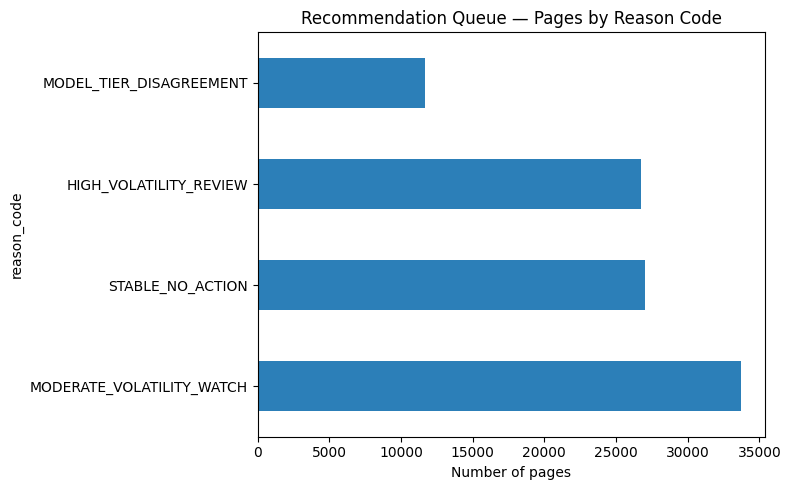

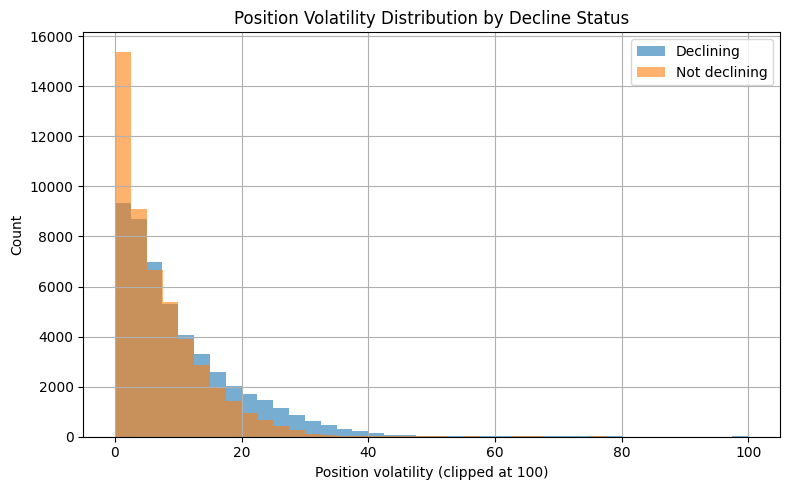

All artifacts saved to work/outputs/


In [18]:
import matplotlib.pyplot as plt
import os
os.makedirs('work/outputs', exist_ok=True)

# Artifact 1: reason code distribution chart
fig, ax = plt.subplots(figsize=(8, 5))
recommendations['reason_code'].value_counts().plot(kind='barh', ax=ax, color='#2c7fb8')
ax.set_xlabel('Number of pages')
ax.set_title('Recommendation Queue — Pages by Reason Code')
plt.tight_layout()
plt.savefig('work/outputs/capstone_reason_code_chart.png', dpi=150)
plt.show()

# Artifact 2: results table (Section 4)
comparison.to_csv('work/outputs/capstone_results_table.csv', index=False)

# Artifact 3: full recommendations queue
recommendations.to_csv('work/outputs/capstone_recommendations.csv', index=False)

# Artifact 4: volatility distribution by declining status (supports Finding A's methodology)
fig, ax = plt.subplots(figsize=(8, 5))
data[data['is_declining']==1]['position_volatility'].clip(upper=100).hist(bins=40, alpha=0.6, label='Declining', ax=ax)
data[data['is_declining']==0]['position_volatility'].clip(upper=100).hist(bins=40, alpha=0.6, label='Not declining', ax=ax)
ax.set_xlabel('Position volatility (clipped at 100)')
ax.set_ylabel('Count')
ax.set_title('Position Volatility Distribution by Decline Status')
ax.legend()
plt.tight_layout()
plt.savefig('work/outputs/capstone_volatility_distribution.png', dpi=150)
plt.show()

print("All artifacts saved to work/outputs/")

Exported four artifacts to work/outputs/ for the deployed paper: capstone_reason_code_chart.png (recommendation distribution), capstone_results_table.csv (Section 4's model-vs-baseline table), capstone_recommendations.csv (the full ranked queue), and capstone_volatility_distribution.png (showing the overlapping, non-clean-separation distribution that explains ML-08's error analysis, declining and non-declining pages visibly overlap rather than forming distinct clusters, visual confirmation of why this is a weak-but-real signal, not a strong one).

## ML-12: Demo, Social Cut & Employer Summary

5-minute demo outline:

(30s) The question: can ranking volatility warn of decline before traffic drops?
(60s) Show the leak I caught, 100% "accuracy" that turned out to be a disguised label.
(90s) The honest result after fixing it: Precision@20 of 0.85, well above the 0.53 base rate.
(60s) The recommendation queue, including the 12% "disagreement" category I built to avoid overclaiming.
(60s) Limitations and what I'd do next with more data.

Social post cut:

Spent my FlyRank ML internship building a content-decline early-warning model, and the best part wasn't the model, it was catching a data leak that gave me a fake 100% accuracy score. Rebuilt it honestly, validated across clients, and shipped a recommendation queue that flags its own uncertainty instead of hiding it.

3-sentence employer-facing summary:

Built and validated an early-warning classifier for content ranking decline using FlyRank's production-scale search data, including identifying and correcting a target-leakage bug that had produced a misleadingly perfect result. Designed a client-grouped validation methodology to ensure findings generalize beyond the training sample, and translated model output into an actionable, uncertainty-aware review queue for a non-technical audience. Comfortable working across the full ML lifecycle: data engineering (DuckDB/SQL at scale), leakage auditing, model validation, and stakeholder-ready communication.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
